# DMMD on MNIST

**Distribution Matching for Diffusion Model Distillation** ([arXiv:2405.06780](https://arxiv.org/abs/2405.06780))

Trains a noise-conditional UNet critic $\phi_\theta$ to maximize the MMD² between clean and noisy data distributions, regularized by L2 + WGAN-GP gradient penalty. Samples are then generated by gradient flow on the learned witness function.

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # MUST be before JAX import

import functools
from etils import ecolab
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import tensorflow_datasets as tfds
import tqdm

with ecolab.adhoc(
    reload=["hackable_diffusion", "kauldron", "lark"],
    invalidate=False,
    cell_autoreload=True,
):
  from hackable_diffusion import hd

gaussian = hd.corruption.gaussian
schedules = hd.corruption.schedules

print(f"Device: {jax.devices()[0]}")

Device: cuda:0


## Data & noise process

In [2]:
# Load MNIST — keep as numpy, only send batches to GPU
ds = tfds.as_numpy(tfds.load('mnist', split='train', batch_size=-1))
all_data = ds['image'].astype(np.float32) / 127.5 - 1.0
all_data = all_data.reshape(-1, 28, 28, 1)
all_data = np.tile(all_data, (1, 1, 1, 3))  # tile to 3ch for UNet compatibility
dataset_size = all_data.shape[0]
print(f'Loaded {dataset_size} samples, shape {all_data.shape} ({all_data.nbytes/1e6:.0f} MB on CPU)')

# Noise process
schedule = schedules.CosineSchedule()
process = gaussian.GaussianProcess(schedule=schedule)
print(f'Noise schedule: {schedule}')

Loaded 60000 samples, shape (60000, 28, 28, 3) (564 MB on CPU)
Noise schedule: <hackable_diffusion.lib.corruption.schedules.CosineSchedule object at 0x3306bd6dfcb0>


## UNet Critic

In [8]:
class ResBlock(nn.Module):
  """ResBlock with AdaGN time conditioning."""
  channels: int

  @nn.compact
  def __call__(self, x, t_emb, is_training=True):
    residual = x
    h = nn.GroupNorm(num_groups=max(1, min(x.shape[-1] // 4, 32)))(x)
    h = jax.nn.silu(h)
    h = nn.Conv(self.channels, (3, 3), padding='SAME')(h)

    t_proj = nn.Dense(2 * self.channels)(jax.nn.silu(t_emb))
    scale, shift = jnp.split(t_proj, 2, axis=-1)
    h = nn.GroupNorm(num_groups=max(1, min(self.channels // 4, 32)))(h)
    h = h * (1 + scale[:, None, None, :]) + shift[:, None, None, :]

    h = jax.nn.silu(h)
    h = nn.Conv(self.channels, (3, 3), padding='SAME',
                kernel_init=nn.initializers.truncated_normal(stddev=1e-8))(h)

    if residual.shape[-1] != self.channels:
      residual = nn.Conv(self.channels, (1, 1))(residual)
    return (residual + h) / jnp.sqrt(2.0)


class UNetCritic(nn.Module):
  """UNet critic with multi-scale feature extraction for DMMD."""
  channels: int = 32
  channel_multipliers: tuple[int, ...] = (1, 2)
  num_residual_blocks: int = 1
  time_embedding_dim: int = 256
  feature_dim_per_stage: int = 32
  use_remat: bool = True

  @nn.compact
  def __call__(self, x, t, is_training=True):
    B = x.shape[0]
    num_levels = len(self.channel_multipliers)
    Block = nn.remat(ResBlock) if self.use_remat else ResBlock

    # Time embedding
    half = self.time_embedding_dim // 2
    freq = jnp.exp(jnp.arange(half) * -(jnp.log(10000.0) / (half - 1)))
    te = jnp.concatenate([jnp.sin(t[:, None] * freq), jnp.cos(t[:, None] * freq)], -1)
    te = jax.nn.silu(nn.Dense(self.time_embedding_dim, name='te0')(te))
    te = nn.Dense(self.time_embedding_dim, name='te1')(te)

    # Encoder
    ch0 = self.channels * self.channel_multipliers[0]
    h = nn.Conv(ch0, (3, 3), padding='SAME', name='in_conv')(x)
    stack = [h]
    pre_down = h

    for i, m in enumerate(self.channel_multipliers):
      ch = self.channels * m
      for j in range(self.num_residual_blocks):
        h = Block(ch, name=f'd{i}_{j}')(h, te, is_training)
        stack.append(h)
      if i < num_levels - 1:
        h = nn.avg_pool(h, (2, 2), strides=(2, 2))
        stack.append(h)
    down = h

    # Middle
    ch_mid = self.channels * self.channel_multipliers[-1]
    h = Block(ch_mid, name='m0')(h, te, is_training)
    h = Block(ch_mid, name='m1')(h, te, is_training)
    mid = h

    # Decoder
    for i in reversed(range(num_levels)):
      ch = self.channels * self.channel_multipliers[i]
      for j in range(self.num_residual_blocks + 1):
        h = jnp.concatenate([h, stack.pop()], axis=-1)
        h = Block(ch, name=f'u{i}_{j}')(h, te, is_training)
      if i > 0:
        h = jax.image.resize(h, (B, h.shape[1]*2, h.shape[2]*2, h.shape[3]), 'nearest')
        h = nn.Conv(self.channels * self.channel_multipliers[i-1], (3, 3),
                    padding='SAME', name=f'up_c{i}')(h)
    assert len(stack) == 0
    up = h

    h = jax.nn.silu(nn.GroupNorm(max(1, min(h.shape[-1]//4, 32)), name='on')(h))
    h = nn.Conv(x.shape[-1], (3, 3), padding='SAME', name='out',
                kernel_init=nn.initializers.truncated_normal(stddev=1e-8))(h)
    last = h

    # Multi-scale features: flatten + Dense
    feats = []
    # for name, tensor in [('pd', pre_down), ('dn', down), ('md', mid), ('up', up), ('la', last)]:
    for name, tensor in [('la', last)]:
      f = jax.nn.silu(nn.GroupNorm(max(1, min(tensor.shape[-1]//4, 32)), name=f'fn_{name}')(tensor))
      f = nn.Dense(self.feature_dim_per_stage, name=f'fp_{name}')(f.reshape(B, -1))
      feats.append(f)
    return jnp.concatenate(feats, axis=-1)


# critic = UNetCritic(channels=28, channel_multipliers=(1, 2, 2), num_residual_blocks=2,
#                     feature_dim_per_stage=32, use_remat=True)

critic = UNetCritic(channels=28, channel_multipliers=(1, 1), num_residual_blocks=1,
                    feature_dim_per_stage=32, use_remat=True)

rng = jax.random.PRNGKey(42)
rng, init_rng = jax.random.split(rng)
params = critic.init({'params': init_rng, 'dropout': init_rng},
                     jnp.ones((1, 28, 28, 3)), jnp.ones((1,)))['params']
num_params = sum(p.size for p in jax.tree.leaves(params))
print(f"Critic: {num_params:,} params, remat=True")

Critic: 479,777 params, remat=True


## DMMD Loss

Single function: MMD² + L2 + gradient penalty, tiled over noise levels. Standard batched VJP for GP.

In [9]:
# ---- Hyperparameters (matching original MMDOptimizationConfig defaults) ----
num_noise_levels = 4
l2_coeff = 0.1
gp_coeff = 1.0
time_eps = 1e-3


def forward_fn(x, t, params):
  """Forward pass through critic."""
  return critic.apply(
      {'params': params}, x, t,
      is_training=True, rngs={'dropout': jax.random.PRNGKey(0)},
  )


def dmmd_loss_fn(params, x0, rng):
  """DMMD loss: -MMD² + L2 + GP.

  Faithful reproduction of _compute_total_loss_optimized from the original
  MMDDiffusionGradientFlowModel.
  """
  B = x0.shape[0]
  ndim = len(x0.shape[1:])  # 3

  rng, trng, nrng, arng = jax.random.split(rng, 4)

  # Sample noise levels
  times = jax.random.uniform(
      trng, (num_noise_levels,), minval=time_eps, maxval=1.0 - time_eps
  )

  # Tile data and time — [NL*B, ...]
  t_rep = jnp.repeat(times, B)                                   # [NL*B]
  x0_rep = jnp.tile(x0, (num_noise_levels,) + (1,) * ndim)       # [NL*B, H, W, C]

  # Corrupt
  xt, _ = process.corrupt(key=nrng, x0=x0_rep, time=t_rep)

  # Forward — single batched call each
  phi_clean = forward_fn(x0_rep, t_rep, params)   # [NL*B, D]
  phi_noisy = forward_fn(xt, t_rep, params)        # [NL*B, D]

  # Reshape to [NL, B, D]
  D = phi_clean.shape[-1]
  phi_c = phi_clean.reshape(num_noise_levels, B, D)
  phi_n = phi_noisy.reshape(num_noise_levels, B, D)

  # ---------- MMD² (unbiased, linear kernel) ----------
  sum_phi_c = jnp.sum(phi_c, axis=1, keepdims=True)   # [NL, 1, D]
  sum_phi_n = jnp.sum(phi_n, axis=1, keepdims=True)

  n_sq = B * B
  n_sq_m1 = B * (B - 1)

  def _dot(x, y):
    return jnp.sum(x * y, axis=-1)

  k_xx = jnp.mean(
      _dot(sum_phi_n, sum_phi_n)
      - jnp.sum(_dot(phi_n, phi_n), axis=1, keepdims=True)
  ) / n_sq_m1

  k_yy = jnp.mean(
      _dot(sum_phi_c, sum_phi_c)
      - jnp.sum(_dot(phi_c, phi_c), axis=1, keepdims=True)
  ) / n_sq_m1

  k_xy = jnp.mean(_dot(sum_phi_n, sum_phi_c)) / n_sq

  mmd_sq = k_xx + k_yy - 2 * k_xy
  total_loss = -mmd_sq

  # ---------- L2 penalty ----------
  l2 = jnp.mean(jnp.sum(phi_n**2 + phi_c**2, axis=-1))
  total_loss += l2_coeff * l2

  # ---------- Gradient penalty (WGAN-GP, original formulation) ----------
  # Interpolate between noisy and clean
  alpha = jax.random.uniform(
      arng, (num_noise_levels * B,) + (1,) * ndim
  )
  mixed = xt * alpha + (1.0 - alpha) * x0_rep   # [NL*B, H, W, C]

  # Per-noise-level witness direction, tiled to [NL*B, D]
  diff = jax.lax.stop_gradient(
      jnp.mean(phi_c - phi_n, axis=1, keepdims=True)   # [NL, 1, D]
  )
  diff = jnp.tile(diff, (1, B, 1)).reshape(num_noise_levels * B, D)

  # witness_train: dot(diff, phi(z)) — per-sample scalar
  def witness_fn(x):
    phi = forward_fn(x, t_rep, params)        # [NL*B, D]
    return jnp.sum(diff * phi, axis=-1)        # [NL*B]

  # Batched per-sample gradient via VJP (original _vgrad pattern)
  def _vgrad(f, x):
    y, vjp_fn = jax.vjp(f, x)
    return vjp_fn(jnp.ones(y.shape))[0]

  witness_grads = _vgrad(witness_fn, mixed)     # [NL*B, H, W, C]
  witness_grads = witness_grads.reshape(num_noise_levels * B, -1)
  grad_norms = jnp.sqrt(
      1e-8 + jnp.sum(jnp.square(witness_grads), axis=-1)
  )
  gp = jnp.mean(jnp.square(grad_norms - 1.0))
  total_loss += gp_coeff * gp

  return total_loss, {
      'mmd_sq': mmd_sq, 'l2': l2, 'gp': gp, 'loss': total_loss,
  }


print(f"Loss config: NL={num_noise_levels}, l2={l2_coeff}, gp={gp_coeff}")

Loss config: NL=4, l2=0.1, gp=1.0


## Training

In [13]:
optimizer = optax.chain(
    optax.clip_by_global_norm(max_norm=1.0),
    optax.scale_by_adam(b1=0.9, b2=0.999, eps=1e-8),
    optax.scale_by_schedule(optax.constant_schedule(value=2e-4)),
    optax.scale(-1.0),
)
opt_state = optimizer.init(params)


@jax.jit
def train_step(params, opt_state, x0, rng):
  grads, metrics = jax.grad(dmmd_loss_fn, has_aux=True)(params, x0, rng)
  updates, opt_state = optimizer.update(grads, opt_state)
  params = optax.apply_updates(params, updates)
  return params, opt_state, metrics


batch_size = 32
nepochs = 20
steps_per_epoch = dataset_size // batch_size

losses, mmd_sqs = [], []
for epoch in tqdm.tqdm(range(1, nepochs + 1)):
  rng, shrng = jax.random.split(rng)
  perm = np.array(jax.random.permutation(shrng, dataset_size))

  ep_loss, ep_mmd, ep_l2, ep_gp = 0.0, 0.0, 0.0, 0.0
  for i in range(steps_per_epoch):
    x0 = jnp.array(all_data[perm[i*batch_size:(i+1)*batch_size]])
    rng, srng = jax.random.split(rng)
    params, opt_state, m = train_step(params, opt_state, x0, srng)
    ep_loss += float(m['loss'])
    ep_mmd += float(m['mmd_sq'])
    ep_l2 += float(m['l2'])
    ep_gp += float(m['gp'])

  n = steps_per_epoch
  losses.append(ep_loss / n)
  mmd_sqs.append(ep_mmd / n)
  print(
      f'Epoch {epoch:2d}  loss={ep_loss/n:.4f}  '
      f'MMD²={ep_mmd/n:.4f}  L2={ep_l2/n:.4f}  GP={ep_gp/n:.4f}'
  )

  5%|▌         | 1/20 [01:34<29:56, 94.57s/it]

Epoch  1  loss=-30.9098  MMD²=1550.1995  L2=778.0146  GP=1441.4882


 10%|█         | 2/20 [02:42<23:35, 78.62s/it]

Epoch  2  loss=-31.0163  MMD²=1551.7946  L2=778.8761  GP=1442.8907


 15%|█▌        | 3/20 [03:48<20:38, 72.85s/it]

...

Epoch 18  loss=-31.3862  MMD²=1533.1580  L2=768.1681  GP=1424.9551


 95%|█████████▌| 19/20 [21:42<01:07, 67.53s/it]

Epoch 19  loss=-30.7256  MMD²=1545.5131  L2=774.6784  GP=1437.3197


100%|██████████| 20/20 [22:54<00:00, 68.71s/it]

Epoch 20  loss=-30.9601  MMD²=1559.5342  L2=781.4278  GP=1450.4313


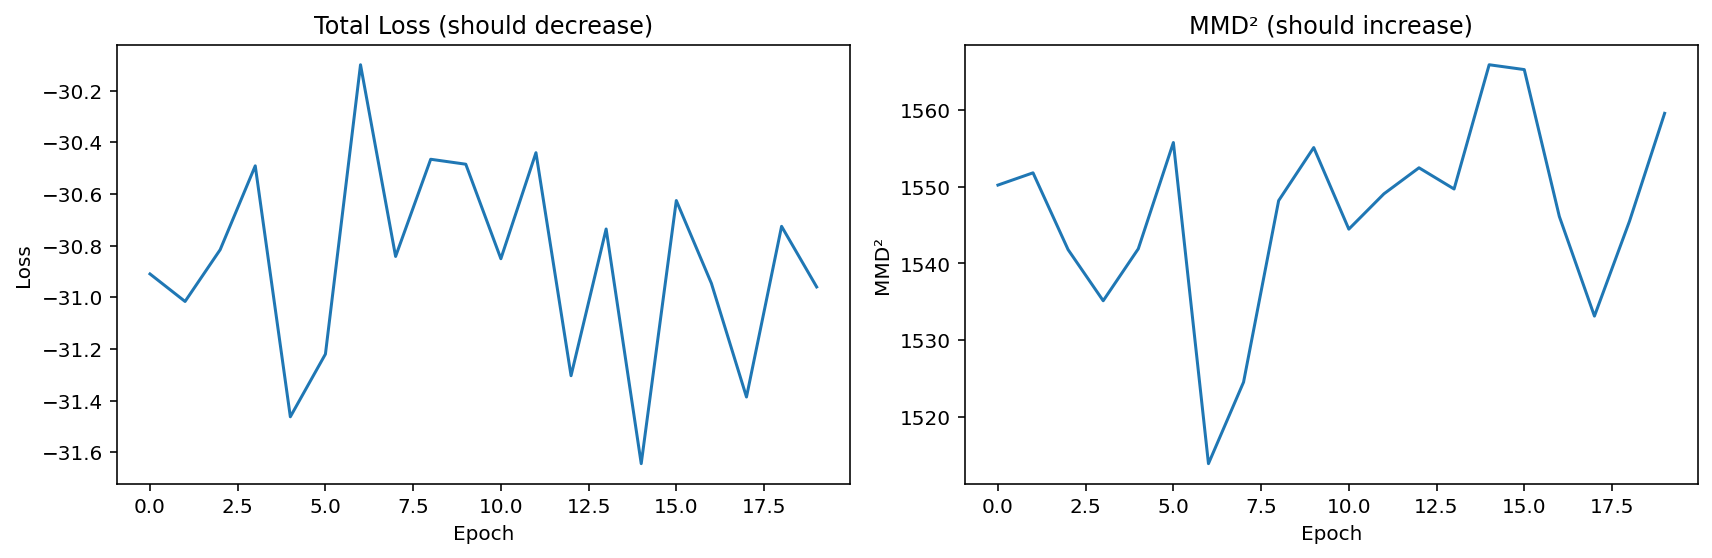

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(losses); ax1.set(xlabel='Epoch', ylabel='Loss', title='Total Loss (should decrease)')
ax2.plot(mmd_sqs); ax2.set(xlabel='Epoch', ylabel='MMD²', title='MMD² (should increase)')
plt.tight_layout(); plt.show()

## Sampling via gradient flow

Starting from noise $z \sim \mathcal{N}(0, I)$, solve the gradient flow $dz/dt = -\nabla_z \text{witness}(z, t)$ backward in time from $t=1$ to $t=0$.

In [15]:
# ---- Sampling: gradient flow on the witness function ----
# Faithful reproduction of witness_f_sampling + sample() from the original.
#
# witness_f(z_i) = <E_loo[φ(Z)] − E[φ(X₀)], φ(z_i)>
#
# where E_loo[φ(Z)] = (Σ_j φ(z_j) − stop_grad(φ(z_i))) / (m−1)
# is the leave-one-out mean of ALL particles (not training data).


@jax.jit
def _gradient_step(xt, phi_clean_mean, t, params, lr):
  """One gradient flow step for all particles."""
  N = xt.shape[0]
  t_arr = jnp.full((N,), t)

  # Pre-compute features for ALL particles (1 batched forward)
  phi_all = forward_fn(xt, t_arr, params)   # [N, D]
  phi_all_sum = jnp.sum(phi_all, axis=0)    # [D]

  def witness_single(z):
    """Witness value for one particle — matches witness_f_sampling."""
    phi_z = forward_fn(z[None], jnp.full((1,), t), params)[0]   # [D]
    # Leave-one-out mean of noisy particles (original formula)
    expected_noisy = (
        phi_all_sum - jax.lax.stop_gradient(phi_z)
    ) / (N - 1)
    expected_clean = phi_clean_mean   # [D]
    return jnp.sum((expected_noisy - expected_clean) * phi_z)

  grads = jax.vmap(jax.grad(witness_single))(xt)   # [N, H, W, C]
  return xt - lr * grads


def sample_dmmd(params, num_samples=64, num_timesteps=10,
                num_steps_per_noise=5, grad_flow_lr=1.0, rng=None):
  """Sample by gradient flow — matches original sample() method."""
  if rng is None:
    rng = jax.random.PRNGKey(0)
  xt = jax.random.normal(rng, (num_samples, 28, 28, 3))

  timesteps = jnp.linspace(1.0 - time_eps, time_eps, num_timesteps)

  for t in tqdm.tqdm(timesteps, desc='Sampling'):
    t = float(t)
    # Compute E[φ(X₀)] from clean training data
    rng, drng = jax.random.split(rng)
    ref_idx = np.array(jax.random.choice(drng, dataset_size, (500,), replace=False))
    ref_x0 = jnp.array(all_data[ref_idx])
    phi_clean = forward_fn(ref_x0, jnp.full((500,), t), params)
    phi_clean_mean = jnp.mean(phi_clean, axis=0)   # [D]

    for _ in range(num_steps_per_noise):
      xt = _gradient_step(xt, phi_clean_mean, t, params, grad_flow_lr)

  return jnp.clip(xt, -1, 1)


print("Sampling function ready (original leave-one-out witness)")

Sampling function ready (original leave-one-out witness)


Sampling: 100%|██████████| 10/10 [00:36<00:00,  3.62s/it]


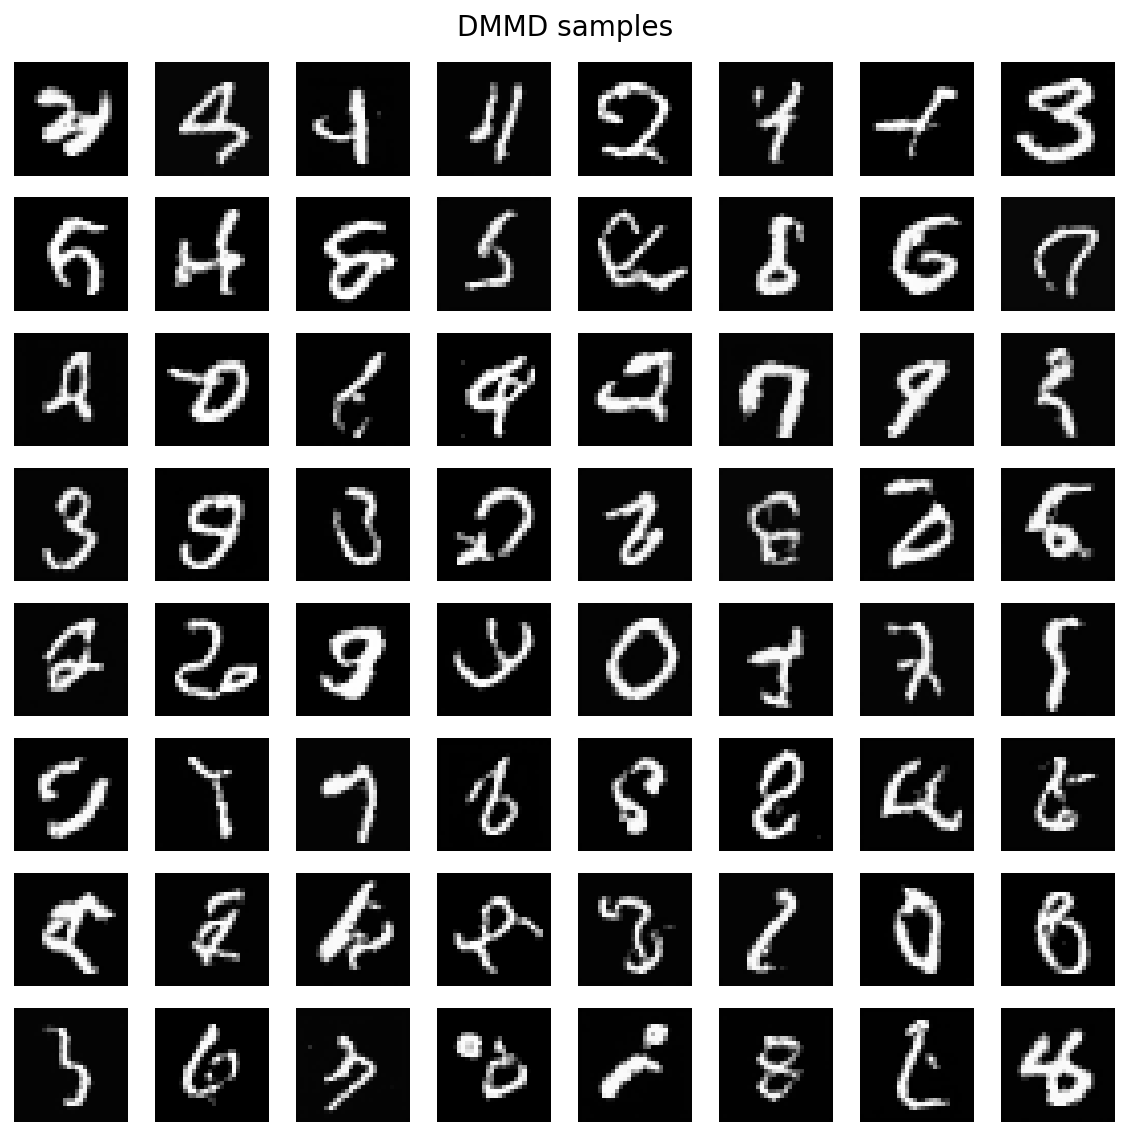

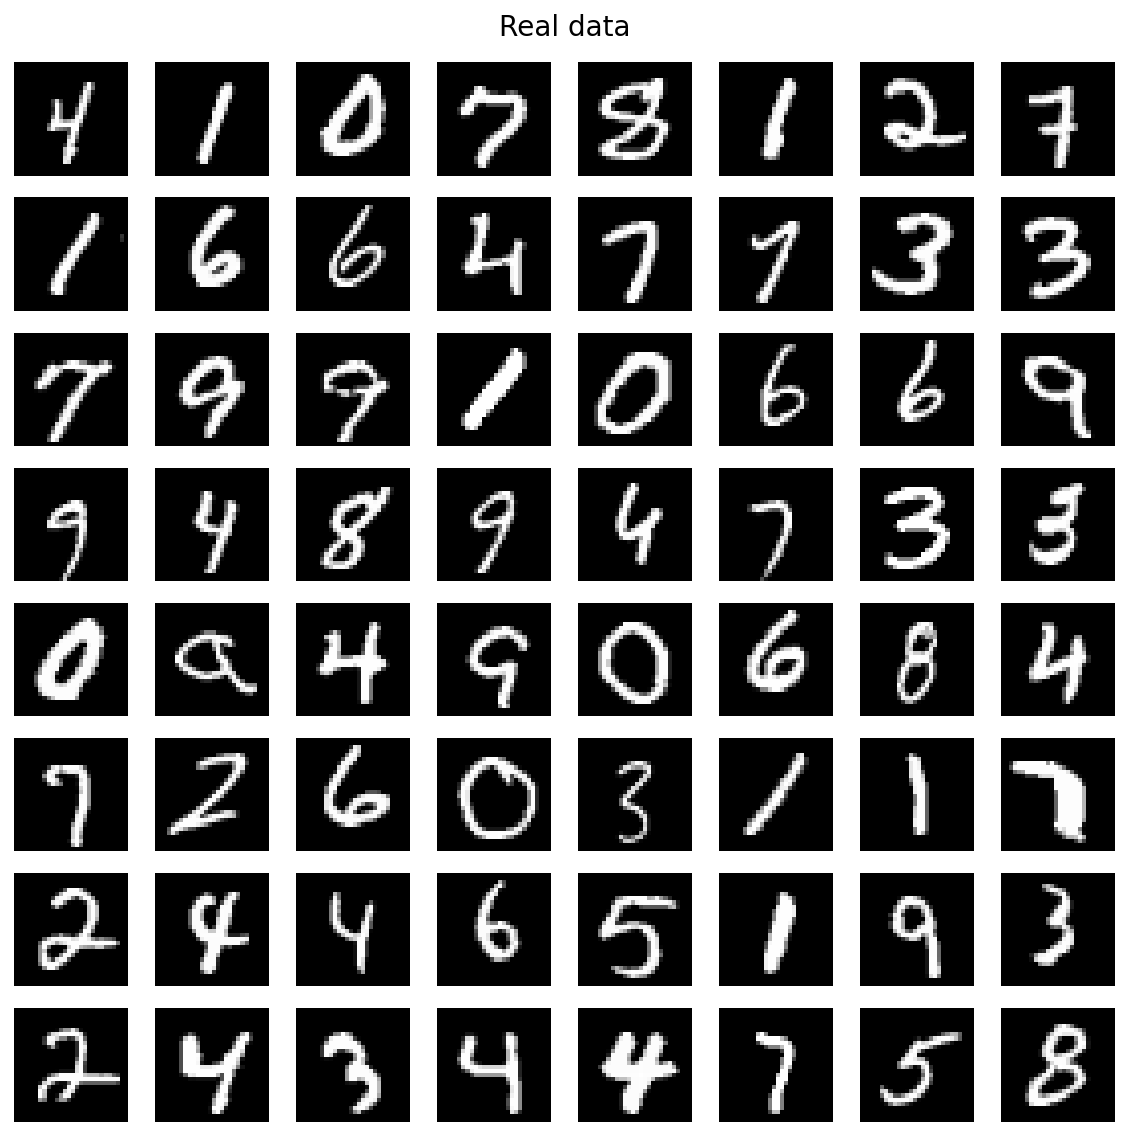

In [16]:
samples = np.array(sample_dmmd(
    params, num_samples=64, num_timesteps=10,
    num_steps_per_noise=10, grad_flow_lr=0.1,
    rng=jax.random.PRNGKey(123),
))

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for img, ax in zip(samples, axes.flatten()):
  ax.imshow((img[:, :, 0] + 1) / 2, cmap='gray', vmin=0, vmax=1)
  ax.axis('off')
fig.suptitle('DMMD samples', fontsize=14)
plt.tight_layout(); plt.show()

# Real data for comparison
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flatten()):
  ax.imshow((all_data[i, :, :, 0] + 1) / 2, cmap='gray', vmin=0, vmax=1)
  ax.axis('off')
fig.suptitle('Real data', fontsize=14)
plt.tight_layout(); plt.show()